In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers , models

In [ ]:
cifar=keras.datasets.cifar10
(x_train,y_train),(x_test,y_test) = cifar.load_data()
x_train,x_test=x_train / 255.0 , x_test / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 390s 2us/step


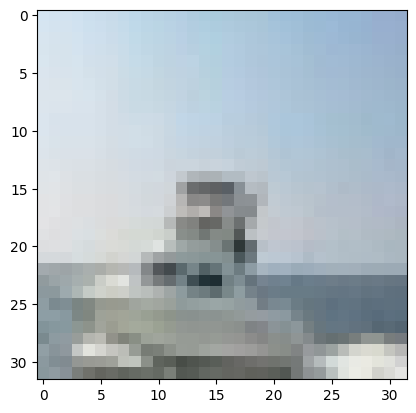

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(x_train[100])

In [ ]:
x_train.shape

(50000, 32, 32, 3)

In [ ]:
model = models.Sequential()
model.add(layers.Conv2D(32,(3,3), activation='relu',input_shape=(32,32,3)))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Conv2D(64,(3,3), activation='relu',input_shape=(32,32,3)))
model.add(layers.Conv2D(64,(3,3), activation='relu'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7744)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       495,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 552,650 (2.11 MB)

 Trainable params: 552,650 (2.11 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

In [ ]:
y_pred=model.predict(x_test)
y_pred[8888]

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


array([ 0.04379591, -0.02124701, -0.02989163, -0.09845623,  0.1373594 ,
       -0.06861127,  0.11172184,  0.07759251, -0.10095431, -0.07186498],
      dtype=float32)

In [ ]:
model.compile(optimizer = 'adam',
              loss ='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history=model.fit(x_train,y_train,validation_split=0.1,epochs=15)

Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 88s 61ms/step - accuracy: 0.1006 - loss: 2.3026 - val_accuracy: 0.0956 - val_loss: 2.3026
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 85s 60ms/step - accuracy: 0.1006 - loss: 2.3026 - val_accuracy: 0.0956 - val_loss: 2.3026
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 88s 62ms/step - accuracy: 0.1006 - loss: 2.3026 - val_accuracy: 0.0956 - val_loss: 2.3026
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 87s 62ms/step - accuracy: 0.1006 - loss: 2.3026 - val_accuracy: 0.0956 - val_loss: 2.3026
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 141s 61ms/step - accuracy: 0.1006 - loss: 2.3026 - val_accuracy: 0.0956 - val_loss: 2.3026
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 88s 63ms/step - accuracy: 0.1006 - loss: 2.3026 - val_accuracy: 0.0956 - val_loss: 2.3026
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 87s 62ms/step - accuracy: 0.1006 - loss: 2.3026 - val_accuracy: 0.0956 - val_loss: 2.3026
Epoch 8/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 142s 62ms/step - accuracy: 0.1006

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()